In [79]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [80]:
df=pd.read_csv('../dataset/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [82]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [83]:
df.duplicated().sum()

np.int64(723)

In [84]:
df.drop_duplicates(inplace=True)

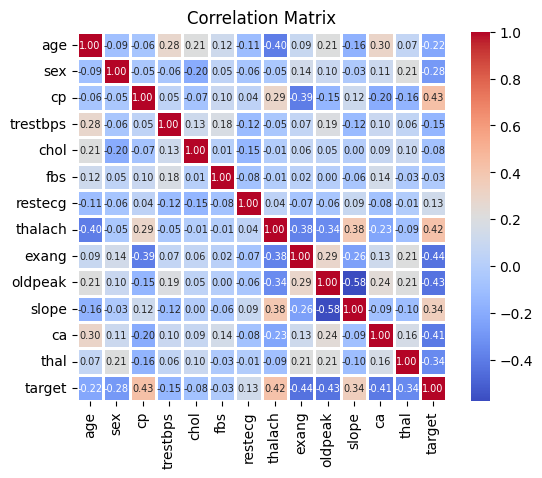

In [85]:
corr_matrix=df.corr()


sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",                 
    cmap="coolwarm",
    linewidths=1,
    square=True,               
    annot_kws={"size": 7}      
)
plt.title('Correlation Matrix')
plt.show()

In [86]:
train_data= df.drop(['target', 'fbs', 'chol', 'restecg'], axis=1)
target=df['target']

In [87]:


from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(train_data,target,test_size=0.2,random_state=42, stratify=target)


In [88]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [89]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)

model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)


In [90]:
print("Predicted values:", y_pred)

Predicted values: [0 1 0 1 1 0 1 0 1 1 1 0 1 1 0 1 1 0 1 1 0 0 1 0 1 0 0 0 0 1 0 1 1 0 0 1 0
 1 1 1 0 1 1 1 0 0 1 0 1 1 0 1 1 0 1 1 0 1 0 0 1]


In [91]:
from sklearn.metrics import accuracy_score

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy*100, "%")

Accuracy: 81.9672131147541 %


In [92]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

In [93]:
rf_model.fit(x_train,y_train)
y_pred_rf=rf_model.predict(x_test)


In [94]:
print("predicted values:", y_pred_rf)

predicted values: [0 1 0 1 1 0 1 0 1 0 1 0 1 1 0 1 1 0 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 1 0 1 0
 1 1 1 1 1 1 1 0 0 1 0 1 0 0 1 1 0 1 1 0 1 0 0 0]


In [95]:
accuracy_rf=accuracy_score(y_test,y_pred_rf)
print("Accuracy:", accuracy_rf*100, "%")

Accuracy: 78.68852459016394 %


In [96]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[22  6]
 [ 5 28]]


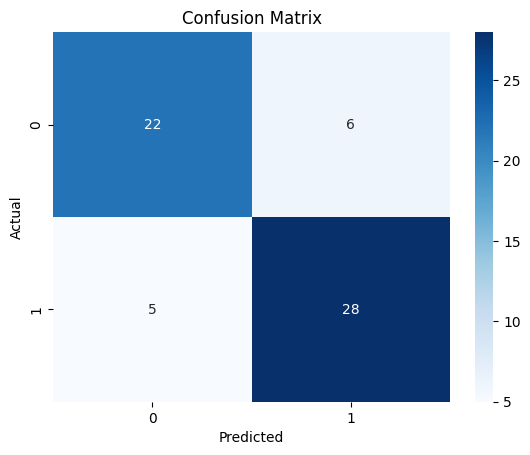

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [98]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.85      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



In [99]:
logistic_accuracy = 81.9672131147541
random_forest_accuracy = 78.68852459016394

In [101]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logistic_accuracy, random_forest_accuracy]
})

print(comparison)

                 Model   Accuracy
0  Logistic Regression  81.967213
1        Random Forest  78.688525
